# Stage 10: the quantum judge

**The task of stage 07, with identical examples and labels, given to
variational quantum classifiers and to classical models with the same
information.** This is the judge used by pipeline variant V4.

Four simulated quantum bits cannot support a claim of quantum advantage in
either direction, and none is made. What the experiment can establish is
narrower and more useful: *how a small quantum circuit's accuracy responds
to more data, compared with classical models of matched and of greater
capacity.*

Two features of the design make that possible.

**A training-set size sweep.** Every model is fitted at 400, 2,000, 8,000
and about 19,900 training rows. Reaching the full corpus at all required
evaluating the circuit on a whole batch of rows in one call, by parameter
broadcasting, rather than once per row: that is roughly 160 times faster
and is what previously confined this stage to a few hundred examples.

**One fixed test set.** The test plans are held out before any fitting and
every model is scored on exactly them. This matters: an earlier version of
this experiment measured small-sample models on a small test set and
full-corpus models on a larger one, and the circuits then appeared to get
*worse* with more data. The capacity-matched control fell by the same
amount, which revealed that the larger test set was simply harder.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

q = pd.read_csv(Path("..") / "data" / "quantum_comparison.csv")
piv = q.pivot_table(index=["kind", "model"], columns="train_rows",
                    values="roc_auc")
piv["gain"] = piv[piv.columns[-1]] - piv[piv.columns[0]]
print("ROC AUC by training-set size, one fixed test set:")
print(piv.round(3).to_string())
print()
print("training time at the largest size (seconds):")
print(q[q.train_rows == q.train_rows.max()][["model", "train_seconds"]]
      .to_string(index=False))

ROC AUC by training-set size, one fixed test set:
train_rows                                                    400   2000   8000  19936   gain
kind      model                                                                              
classical boosting, all 6 measurements                      0.790  0.841  0.860  0.865  0.075
          boosting, same 4 measurements                     0.705  0.753  0.779  0.789  0.084
          logistic, same 4 measurements (capacity-matched)  0.747  0.749  0.746  0.746 -0.001
quantum   VQC, one encoding, 2 layers                       0.741  0.751  0.734  0.748  0.007
          data re-uploading, 6 layers                       0.741  0.761  0.756  0.746  0.005

training time at the largest size (seconds):
                                           model  train_seconds
                     VQC, one encoding, 2 layers           40.3
                     data re-uploading, 6 layers          251.4
logistic, same 4 measurements (capacity-matched)      

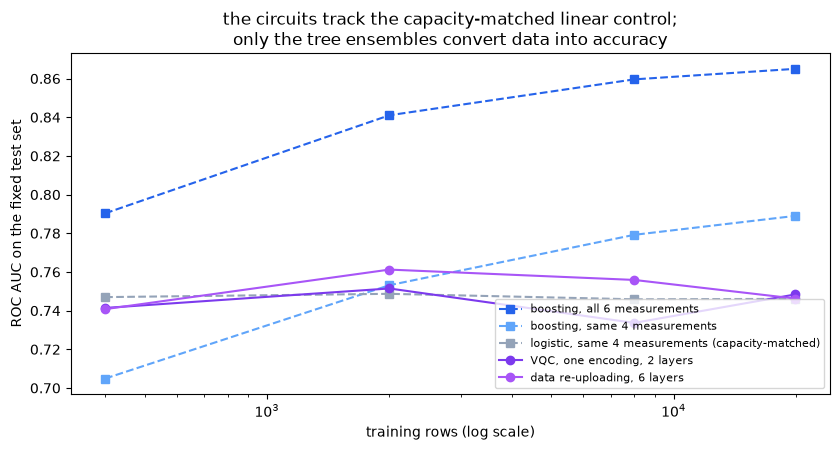

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
style = {"quantum": dict(marker="o", ls="-"),
         "classical": dict(marker="s", ls="--")}
colour = {"VQC, one encoding, 2 layers": "#7c3aed",
          "data re-uploading, 6 layers": "#a855f7",
          "logistic, same 4 measurements (capacity-matched)": "#94a3b8",
          "boosting, same 4 measurements": "#60a5fa",
          "boosting, all 6 measurements": "#2563eb"}
for (kind, model), grp in q.groupby(["kind", "model"]):
    grp = grp.sort_values("train_rows")
    ax.plot(grp.train_rows, grp.roc_auc, color=colour[model],
            label=model, **style[kind])
ax.set_xscale("log")
ax.set_xlabel("training rows (log scale)")
ax.set_ylabel("ROC AUC on the fixed test set")
ax.set_title("the circuits track the capacity-matched linear control;\n"
             "only the tree ensembles convert data into accuracy")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
fig.savefig(Path("..") / "figures" / "10_quantum_vs_classical.png", dpi=150,
            bbox_inches="tight")
plt.show()

## What the sweep shows

**Given the same information, the circuits match their capacity-matched
control.** At every size the two quantum models sit within about 0.015 of
logistic regression on the same four measurements, and at 2,000 rows they
are slightly ahead. A four-qubit circuit can learn this task.

**More data buys the circuits almost nothing.** Fifty times more training
data moves them by +0.007 and +0.005, which is inside run-to-run
variation. The capacity-matched linear control behaves the same way
(−0.001). The tree ensembles, which have real flexibility, convert the
identical data into +0.075 and +0.084.

**So the limit is capacity, not data.** The circuits improve with data the
way a linear model does, not the way a flexible model does, which locates
the ceiling in the expressive capacity of four qubits and two entangling
layers rather than in the size of the corpus. That conclusion is not
available from a single small-sample run, and it is why the experiment
sweeps the training size instead of reporting one number.

**The cost asymmetry is part of the result.** At the largest size the
plain circuit took 40 seconds of simulation and the re-uploading circuit
251, against 3 to 5 seconds for the tree ensembles and under a second for
logistic regression, to reach a lower score.

## The judge the pipeline uses

Variant V4 trains a plain two-layer circuit on the whole corpus, so that
all three judges see identical data. Since the sweep shows the extra rows
buy the circuit almost nothing, this costs about fifty seconds at start-up
and removes any objection that the quantum arm was given less data than
the others. Stage 12 then measures what V4 does to end-to-end accuracy,
which is the only question a pipeline finally owes an answer to.